In [83]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import mlflow
import mlflow.sklearn
import shap
import matplotlib.pyplot as plt
import lime
import lime.lime_tabular

In [84]:
df = pd.read_csv("dataset-uci.csv")
df.head()

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6


In [85]:
df.isnull().sum()

Gallstone Status                                  0
Age                                               0
Gender                                            0
Comorbidity                                       0
Coronary Artery Disease (CAD)                     0
Hypothyroidism                                    0
Hyperlipidemia                                    0
Diabetes Mellitus (DM)                            0
Height                                            0
Weight                                            0
Body Mass Index (BMI)                             0
Total Body Water (TBW)                            0
Extracellular Water (ECW)                         0
Intracellular Water (ICW)                         0
Extracellular Fluid/Total Body Water (ECF/TBW)    0
Total Body Fat Ratio (TBFR) (%)                   0
Lean Mass (LM) (%)                                0
Body Protein Content (Protein) (%)                0
Visceral Fat Rating (VFR)                         0
Bone Mass (B

In [86]:
df.duplicated().sum()

np.int64(0)

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                319 non-null    int64  
 1   Age                                             319 non-null    int64  
 2   Gender                                          319 non-null    int64  
 3   Comorbidity                                     319 non-null    int64  
 4   Coronary Artery Disease (CAD)                   319 non-null    int64  
 5   Hypothyroidism                                  319 non-null    int64  
 6   Hyperlipidemia                                  319 non-null    int64  
 7   Diabetes Mellitus (DM)                          319 non-null    int64  
 8   Height                                          319 non-null    int64  
 9   Weight                                     

In [88]:
df.describe()

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
count,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.00000,319.000000,...,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000
mean,0.495298,48.068966,0.492163,0.335423,0.037618,0.028213,0.025078,0.134796,167.15674,80.564890,...,49.475549,144.502163,21.684953,26.855799,73.112539,0.800611,100.818903,1.853856,14.418182,21.401411
std,0.500763,12.114558,0.500724,0.517340,0.190568,0.165841,0.156609,0.342042,10.05303,15.709069,...,17.718701,97.904493,16.697605,27.884413,24.181069,0.176433,16.971396,4.989591,1.775815,9.981659
min,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,145.00000,42.900000,...,25.000000,1.390000,8.000000,3.000000,7.000000,0.460000,10.600000,0.000000,8.500000,3.500000
25%,0.000000,38.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,159.50000,69.600000,...,40.000000,83.000000,15.000000,14.250000,58.000000,0.650000,94.170000,0.000000,13.300000,13.250000
50%,0.000000,49.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,168.00000,78.800000,...,46.500000,119.000000,18.000000,19.000000,71.000000,0.790000,104.000000,0.215000,14.400000,22.000000
75%,1.000000,56.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,175.00000,91.250000,...,56.000000,172.000000,23.000000,30.000000,86.000000,0.920000,110.745000,1.615000,15.700000,28.060000
max,1.000000,96.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,191.00000,143.500000,...,273.000000,838.000000,195.000000,372.000000,197.000000,1.460000,132.000000,43.400000,18.800000,53.100000


In [89]:
X = df.drop(['Gallstone Status'], axis=1)
y = df['Gallstone Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Random Forest

In [ ]:
rf = RandomForestClassifier(random_state=42)

param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 'log2']}

grid = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, return_train_score=True)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
best_rf = grid.best_estimator_

results = pd.DataFrame(grid.cv_results_)
param_cols = [c for c in results.columns if c.startswith("param_")]
grid_table = results[param_cols + ["mean_train_score","mean_test_score","rank_test_score"]].sort_values("rank_test_score")
display(grid_table)

Best Parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_n_estimators,mean_train_score,mean_test_score,rank_test_score
36,None,log2,2,2,100,1.000000,0.803922,1
39,None,log2,2,5,100,0.999020,0.800000,2
144,10,log2,2,2,100,0.999020,0.800000,2
147,10,log2,2,5,100,0.999020,0.800000,2
145,10,log2,2,2,200,1.000000,0.796078,5
...,...,...,...,...,...,...,...,...
115,10,sqrt,1,10,200,0.993137,0.756863,156
48,None,log2,4,5,100,0.971569,0.756863,156
153,10,log2,4,2,100,0.972549,0.756863,156
43,None,log2,2,10,200,0.991176,0.752941,161


In [91]:
y_pred_train = best_rf.predict(X_train_scaled)
y_pred_test  = best_rf.predict(X_test_scaled)
y_proba_test = best_rf.predict_proba(X_test_scaled)[:, 1]# For ROC AUC

train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test, y_pred_test)

test_roc = roc_auc_score(y_test, y_proba_test)
test_precision = precision_score(y_test, y_pred_test, zero_division=0)
test_recall = recall_score(y_test, y_pred_test, zero_division=0)
test_f1 = f1_score(y_test, y_pred_test, zero_division=0)

with mlflow.start_run(run_name="RandomForest_Gallstone"):
    mlflow.log_params(grid.best_params_)
    mlflow.log_metric("cv_mean_train_acc", grid_table.iloc[0]["mean_train_score"])
    mlflow.log_metric("cv_mean_val_acc", grid_table.iloc[0]["mean_test_score"])

    mlflow.log_metric("train_acc", train_acc)
    mlflow.log_metric("test_acc", test_acc)
    mlflow.log_metric("roc_auc", test_roc)
    mlflow.log_metric("precision", test_precision)
    mlflow.log_metric("recall", test_recall)
    mlflow.log_metric("f1_score", test_f1)

    mlflow.sklearn.log_model(best_rf, "random_forest_model")

2026/01/21 19:27:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [92]:
print("CV mean TRAIN acc:", grid_table.iloc[0]["mean_train_score"])
print("CV mean VAL acc:", grid_table.iloc[0]["mean_test_score"])
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("AUC:", test_roc)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1 Score:", test_f1)

CV mean TRAIN acc: 1.0
CV mean VAL acc: 0.803921568627451
Train Accuracy: 1.0
Test Accuracy: 0.796875
AUC: 0.8709677419354839
Precision: 0.78125
Recall: 0.8064516129032258
F1 Score: 0.7936507936507936


XGBoost

In [ ]:
xgb = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)

param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7],'learning_rate': [0.01, 0.1, 0.2], 'subsample': [0.8, 1.0], 'colsample_bytree': [0.8, 1.0]}

grid = GridSearchCV(
    xgb,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
best_xgb = grid.best_estimator_

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}


In [94]:
results = pd.DataFrame(grid.cv_results_)
param_cols = [c for c in results.columns if c.startswith("param_")]
grid_table = results[param_cols + ["mean_train_score","mean_test_score","rank_test_score"]].sort_values("rank_test_score")
display(grid_table)

,param_colsample_bytree,param_learning_rate,param_max_depth,param_n_estimators,param_subsample,mean_train_score,mean_test_score,rank_test_score
45,0.8,0.20,5,200,1.0,1.000000,0.788235,1
40,0.8,0.20,3,300,0.8,1.000000,0.784314,2
47,0.8,0.20,5,300,1.0,1.000000,0.784314,2
26,0.8,0.10,5,200,0.8,1.000000,0.784314,4
41,0.8,0.20,3,300,1.0,1.000000,0.784314,4
...,...,...,...,...,...,...,...,...
63,1.0,0.01,5,200,1.0,0.985294,0.721569,104
103,1.0,0.20,7,100,1.0,1.000000,0.721569,105
1,0.8,0.01,3,100,1.0,0.901961,0.717647,106
67,1.0,0.01,7,100,1.0,0.962745,0.709804,107


In [95]:
y_pred_train = best_xgb.predict(X_train_scaled)
y_pred_test  = best_xgb.predict(X_test_scaled)
y_proba_test = best_xgb.predict_proba(X_test_scaled)[:, 1]# For ROC AUC

train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test, y_pred_test)

test_roc = roc_auc_score(y_test, y_proba_test)
test_precision = precision_score(y_test, y_pred_test, zero_division=0)
test_recall = recall_score(y_test, y_pred_test, zero_division=0)
test_f1 = f1_score(y_test, y_pred_test, zero_division=0)


with mlflow.start_run(run_name="XGBoost_Gallstone"):
    mlflow.log_params(grid.best_params_)
    mlflow.log_metric("cv_mean_train_acc", grid_table.iloc[0]["mean_train_score"])
    mlflow.log_metric("cv_mean_val_acc", grid_table.iloc[0]["mean_test_score"])
    mlflow.log_metric("train_acc", train_acc)
    mlflow.log_metric("test_acc", test_acc)
    mlflow.log_metric("roc_auc", test_roc)
    mlflow.log_metric("precision", test_precision)
    mlflow.log_metric("recall", test_recall)
    mlflow.log_metric("f1_score", test_f1)

    mlflow.sklearn.log_model(best_xgb, "xgboost_model")

2026/01/21 19:27:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [96]:
print("CV mean TRAIN acc:", grid_table.iloc[0]["mean_train_score"])
print("CV mean VAL acc:", grid_table.iloc[0]["mean_test_score"])
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("ROC AUC:", test_roc)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1 Score:", test_f1)

CV mean TRAIN acc: 1.0
CV mean VAL acc: 0.7882352941176471
Train Accuracy: 1.0
Test Accuracy: 0.875
ROC AUC: 0.9100684261974584
Precision: 0.8709677419354839
Recall: 0.8709677419354839
F1 Score: 0.8709677419354839


SVM

In [ ]:
svm = SVC(probability=True, random_state=42)

param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}

grid = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1, return_train_score=True)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
best_svm = grid.best_estimator_

results = pd.DataFrame(grid.cv_results_)
param_cols = [c for c in results.columns if c.startswith("param_")]
grid_table = results[param_cols + ["mean_train_score","mean_test_score","rank_test_score"]].sort_values("rank_test_score")
display(grid_table)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


,param_C,param_gamma,param_kernel,mean_train_score,mean_test_score,rank_test_score
6,1.0,auto,linear,0.863725,0.788235,1
4,1.0,scale,linear,0.863725,0.788235,1
10,10.0,auto,linear,0.883333,0.784314,3
8,10.0,scale,linear,0.883333,0.784314,3
0,0.1,scale,linear,0.850980,0.764706,5
2,0.1,auto,linear,0.850980,0.764706,5
5,1.0,scale,rbf,0.903922,0.737255,7
7,1.0,auto,rbf,0.902941,0.737255,7
9,10.0,scale,rbf,0.985294,0.717647,9
11,10.0,auto,rbf,0.985294,0.717647,9


In [98]:
y_pred_train = best_svm.predict(X_train_scaled)
y_pred_test  = best_svm.predict(X_test_scaled)
y_proba_test = best_svm.predict_proba(X_test_scaled)[:, 1]# For ROC AUC

train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test, y_pred_test)

test_roc = roc_auc_score(y_test, y_proba_test)
test_precision = precision_score(y_test, y_pred_test, zero_division=0)
test_recall = recall_score(y_test, y_pred_test, zero_division=0)
test_f1 = f1_score(y_test, y_pred_test, zero_division=0)
with mlflow.start_run(run_name="SVM_Gallstone"):
    mlflow.log_params(grid.best_params_)
    mlflow.log_metric("cv_mean_train_acc", grid_table.iloc[0]["mean_train_score"])
    mlflow.log_metric("cv_mean_val_acc", grid_table.iloc[0]["mean_test_score"])

    mlflow.log_metric("train_acc", train_acc)
    mlflow.log_metric("test_acc", test_acc)
    mlflow.log_metric("roc_auc", test_roc)
    mlflow.log_metric("precision", test_precision)
    mlflow.log_metric("recall", test_recall)
    mlflow.log_metric("f1_score", test_f1)
    mlflow.sklearn.log_model(best_svm, "svm_model")

2026/01/21 19:27:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [99]:
print("CV mean TRAIN acc:", grid_table.iloc[0]["mean_train_score"])
print("CV mean VAL acc:", grid_table.iloc[0]["mean_test_score"])
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("ROC AUC:", test_roc)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1 Score:", test_f1)

CV mean TRAIN acc: 0.8637254901960784
CV mean VAL acc: 0.7882352941176471
Train Accuracy: 0.8745098039215686
Test Accuracy: 0.796875
ROC AUC: 0.9022482893450635
Precision: 0.8461538461538461
Recall: 0.7096774193548387
F1 Score: 0.7719298245614035


Decision Trees

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

param_grid = {'max_depth': [None, 3, 5, 7, 10], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}

grid = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy', n_jobs=-1, return_train_score=True)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
best_dt = grid.best_estimator_

results = pd.DataFrame(grid.cv_results_)
param_cols = [c for c in results.columns if c.startswith("param_")]
grid_table = results[param_cols + ["mean_train_score","mean_test_score","rank_test_score"]].sort_values("rank_test_score")
display(grid_table)

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}


,param_max_depth,param_min_samples_leaf,param_min_samples_split,mean_train_score,mean_test_score,rank_test_score
15,3,4,2,0.833333,0.698039,1
16,3,4,5,0.833333,0.698039,1
17,3,4,10,0.833333,0.698039,1
13,3,2,5,0.838235,0.694118,4
14,3,2,10,0.838235,0.694118,4
12,3,2,2,0.838235,0.694118,4
11,3,1,10,0.840196,0.690196,7
9,3,1,2,0.840196,0.690196,7
10,3,1,5,0.840196,0.690196,7
25,5,4,5,0.889216,0.686275,10


In [101]:
y_pred_train = best_dt.predict(X_train_scaled)
y_pred_test  = best_dt.predict(X_test_scaled)
y_proba_test = best_dt.predict_proba(X_test_scaled)[:, 1]# For ROC AUC

train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test, y_pred_test)

test_roc = roc_auc_score(y_test, y_proba_test)
test_precision = precision_score(y_test, y_pred_test, zero_division=0)
test_recall = recall_score(y_test, y_pred_test, zero_division=0)
test_f1 = f1_score(y_test, y_pred_test, zero_division=0)


with mlflow.start_run(run_name="DecisionTree_Gallstone"):
    mlflow.log_params(grid.best_params_)
    mlflow.log_metric("cv_mean_train_acc", grid_table.iloc[0]["mean_train_score"])
    mlflow.log_metric("cv_mean_val_acc", grid_table.iloc[0]["mean_test_score"])
    mlflow.log_metric("train_acc", train_acc)
    mlflow.log_metric("test_acc", test_acc)
    mlflow.log_metric("roc_auc", test_roc)
    mlflow.log_metric("precision", test_precision)
    mlflow.log_metric("recall", test_recall)
    mlflow.log_metric("f1_score", test_f1)
    mlflow.sklearn.log_model(best_dt, "decision_tree_model")

2026/01/21 19:27:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [102]:
print("CV mean TRAIN acc:", grid_table.iloc[0]["mean_train_score"])
print("CV mean VAL acc:", grid_table.iloc[0]["mean_test_score"])
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("ROC AUC:", test_roc)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1 Score:", test_f1)

CV mean TRAIN acc: 0.8333333333333334
CV mean VAL acc: 0.6980392156862745
Train Accuracy: 0.8156862745098039
Test Accuracy: 0.65625
ROC AUC: 0.7776148582600195
Precision: 0.7368421052631579
Recall: 0.45161290322580644
F1 Score: 0.56


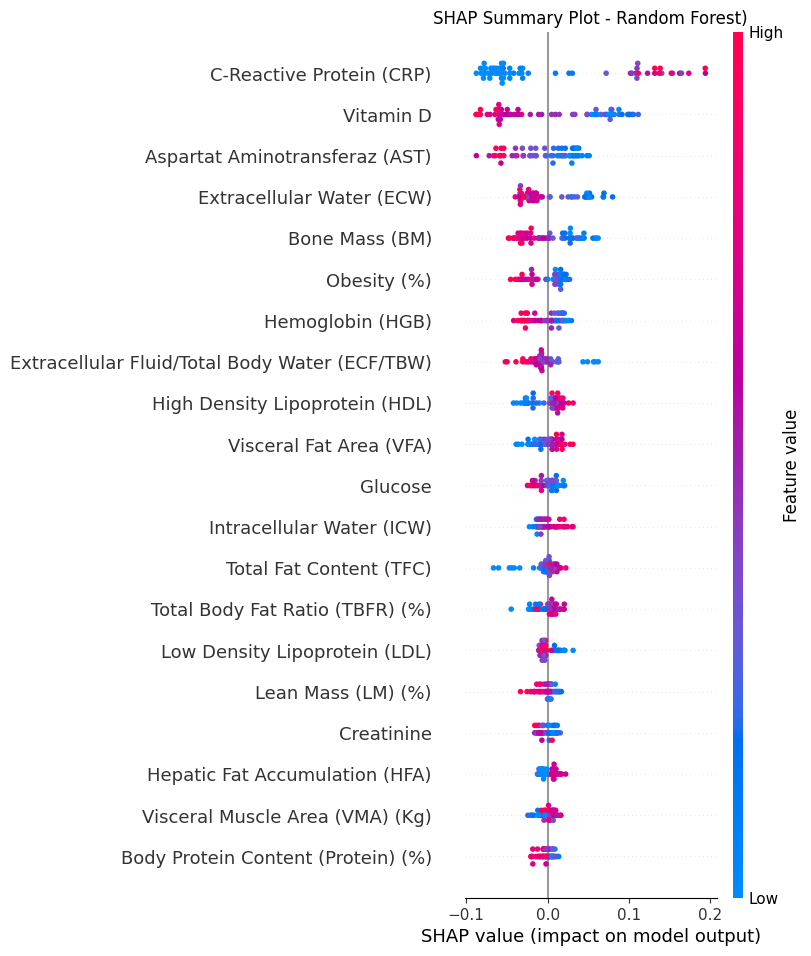

In [ ]:
feature_names = X_train.columns
#Convert the scaled training and testing data back into a dataframe
X_train_used = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_used  = pd.DataFrame(X_test_scaled, columns=feature_names)

explainer_rf = shap.Explainer(best_rf, X_train_used) #Initialize the SHAP explainer for the random forest
shap_values_rf = explainer_rf(X_test_used, check_additivity=False) #Compute SHAP values for the test dataset

shap_values_class1 = shap_values_rf[:, :, 1] #Extract SHAP values corresponding to the positive class

shap.summary_plot(shap_values_class1, X_test_used, show=False) #Generate a SHAP summary plot
plt.title("SHAP Summary Plot - Random Forest)")
plt.show()

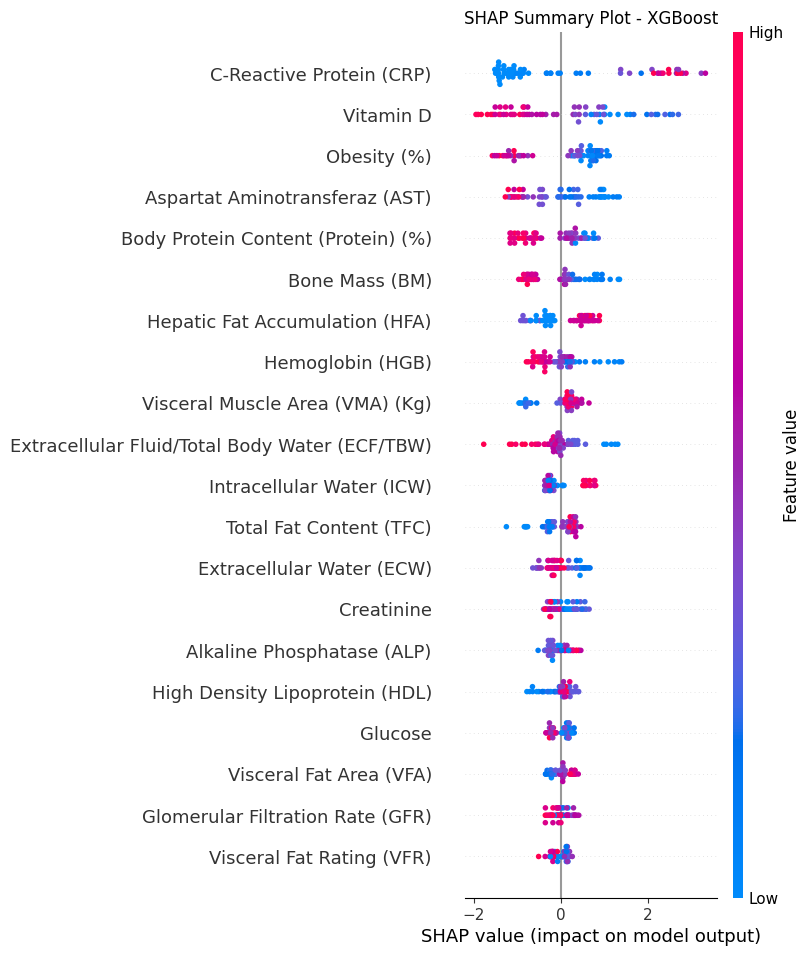

In [ ]:
explainer_xgb = shap.Explainer(best_xgb, X_train_used) #Initialize the SHAP explainer for the XGBoost
shap_values_xgb = explainer_xgb(X_test_used, check_additivity=False) #Compute SHAP values for the test dataset
shap.summary_plot(shap_values_xgb, X_test_used, show=False) #Generate a SHAP summary plot
plt.title("SHAP Summary Plot - XGBoost")
plt.show()

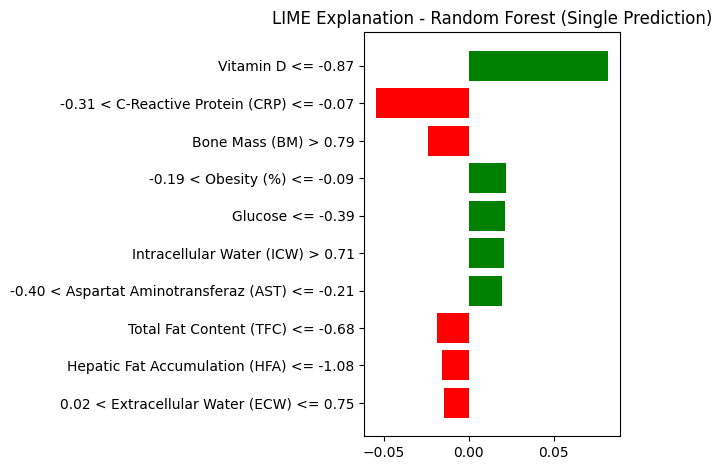

In [ ]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(training_data=X_train_used.values, feature_names=X_train_used.columns,
                                                        class_names=['Class 0', 'Class 1'], mode='classification')
i = 0 #The index of the test instance to be explained

instance_to_explain = X_test_used.iloc[i] #Extract the test sample for local explanation

explainer_rf = explainer_lime.explain_instance(data_row=instance_to_explain.values, predict_fn=best_rf.predict_proba, num_features=10) 
fig = explainer_rf.as_pyplot_figure() #Convert the LIME explanation into a matplotlib figure for visualization
plt.title(f"LIME Explanation - Random Forest (Single Prediction)")
plt.tight_layout()
plt.show()

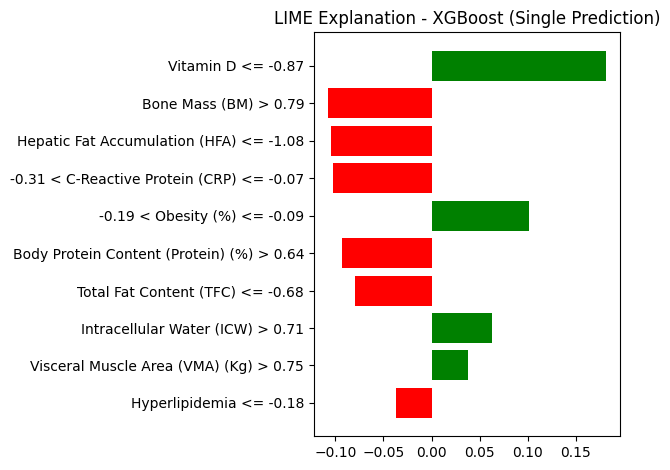

In [ ]:
explainer_xgb = explainer_lime.explain_instance(data_row=instance_to_explain.values, predict_fn=best_xgb.predict_proba, num_features=10)
fig = explainer_xgb.as_pyplot_figure() #Convert the LIME explanation into a matplotlib figure for visualization
plt.title(f"LIME Explanation - XGBoost (Single Prediction)")
plt.tight_layout()
plt.show()